# 四模型全面对比: SenseVoice & Fun-ASR-Nano (基线 vs 微调)

在**全量**验证集上串行评估四个模型：
1. **SenseVoice-base**: 未微调基线
2. **SenseVoice-ft**: 微调后
3. **Nano-base**: 未微调基线
4. **Nano-ft**: 微调后

适配 Mac MPS 本地环境，逐个模型加载/评估/释放，避免内存不足。

## 1. 环境检查

In [1]:
import warnings
import logging
logging.getLogger('root').setLevel(logging.ERROR)
warnings.filterwarnings('ignore')

import os, re, json, time, gc
import torch

device = 'mps' if torch.backends.mps.is_available() else 'cpu'
print(f'PyTorch: {torch.__version__}')
print(f'Device: {device}')

import funasr
print(f'FunASR: {funasr.__version__}')

try:
    import matplotlib
    matplotlib.use('Agg')
    import matplotlib.pyplot as plt
    print(f'matplotlib: {matplotlib.__version__}')
except ImportError:
    print('matplotlib 未安装，可视化步骤将跳过')

import editdistance
print(f'editdistance: OK')

print('\n--- 路径检查 ---')
paths = {
    'SenseVoice 微调': os.path.expanduser('~/Projects/Agent/model/sensevoice_lora/model.pt.best'),
    'Nano 微调': os.path.expanduser('~/Projects/Agent/model/funasr_nano_v3/model.pt.best'),
    '验证集': os.path.expanduser('~/Desktop/hengdong_asr_trainset/manifests/val.jsonl'),
    '长音频数据': os.path.expanduser('~/Desktop/hengdong_asr_trainset/manifests/extra_long_talks.jsonl'),
}
for name, path in paths.items():
    print(f'  {name}: {"OK" if os.path.exists(path) else "NOT FOUND"} - {path}')

PyTorch: 2.11.0
Device: mps
FunASR: 1.3.1
matplotlib: 3.10.9
editdistance: OK

--- 路径检查 ---
  SenseVoice 微调: OK - /Users/fanhua/Projects/Agent/model/sensevoice_lora/model.pt.best
  Nano 微调: OK - /Users/fanhua/Projects/Agent/model/funasr_nano_v3/model.pt.best
  验证集: OK - /Users/fanhua/Desktop/hengdong_asr_trainset/manifests/val.jsonl
  长音频数据: OK - /Users/fanhua/Desktop/hengdong_asr_trainset/manifests/extra_long_talks.jsonl


## 2. 工具函数与数据加载

In [2]:
def clean_sensevoice_text(text):
    """去除 SenseVoice 特殊标记"""
    return re.sub(r'<\|[^|]*\|>', '', text).strip()

def levenshtein(s1, s2):
    if len(s1) < len(s2):
        return levenshtein(s2, s1)
    if len(s2) == 0:
        return len(s1)
    prev = list(range(len(s2) + 1))
    for c1 in s1:
        curr = [prev[0] + 1]
        for j, c2 in enumerate(s2):
            curr.append(min(prev[j + 1] + 1, curr[j] + 1, prev[j] + (c1 != c2)))
        prev = curr
    return prev[-1]

def free_memory():
    gc.collect()
    if torch.backends.mps.is_available():
        torch.mps.empty_cache()

print('工具函数就绪')

工具函数就绪


In [3]:
# 加载全量验证集
DATA_ROOT = os.path.expanduser('~/Desktop/hengdong_asr_trainset')
VAL_JSONL = os.path.join(DATA_ROOT, 'manifests/val.jsonl')

samples = []
with open(VAL_JSONL, 'r', encoding='utf-8') as f:
    for line in f:
        s = json.loads(line)
        audio = s.get('audio_filepath') or s.get('source')
        if audio and os.path.exists(audio):
            samples.append(s)

print(f'验证集: {len(samples)} 条有效样本')
print(f'\n前3条:')
for s in samples[:3]:
    audio = s.get('audio_filepath') or s.get('source')
    text = s.get('text') or s.get('target')
    print(f'  {os.path.basename(audio)} -> {text}')

验证集: 2261 条有效样本

前3条:
  backend_user_1769774772513_1_1.wav -> 爱
  backend_user_1769774772513_20_20.wav -> 东西
  backend_user_1769774772513_24_24.wav -> 多


## 3. 串行评估函数

In [4]:
from funasr import AutoModel

SV_CKPT = os.path.expanduser('~/Projects/Agent/model/sensevoice_lora/model.pt.best')
NANO_CKPT = os.path.expanduser('~/Projects/Agent/model/funasr_nano_v3/model.pt.best')

def eval_sensevoice(model, samples, label):
    """评估 SenseVoice 模型"""
    results = []
    total_cer, total_chars, exact = 0.0, 0, 0
    start = time.time()
    for i, s in enumerate(samples):
        audio = s.get('audio_filepath') or s.get('source')
        expected = s.get('text') or s.get('target')
        if not audio or not os.path.exists(audio):
            continue
        try:
            res = model.generate(input=audio, language='auto', use_itn=True)
            pred = clean_sensevoice_text(res[0]['text']) if res else ''
        except:
            pred = ''
        dist = levenshtein(expected, pred)
        ref_len = max(len(expected), 1)
        cer = dist / ref_len
        total_cer += dist
        total_chars += ref_len
        if expected == pred:
            exact += 1
        results.append({'id': i, 'expected': expected, 'predicted': pred, 'cer': cer})
        if (i + 1) % 100 == 0:
            print(f'    {label}: {i+1}/{len(samples)} | CER={total_cer/total_chars:.2%} | exact={exact}')
    cer = total_cer / total_chars if total_chars > 0 else 0
    elapsed = time.time() - start
    return {'name': label, 'results': results, 'cer': cer, 'exact': exact, 'total': len(results), 'time': elapsed}

def eval_nano(model, samples, label):
    """评估 Fun-ASR-Nano 模型"""
    results = []
    total_cer, total_chars, exact = 0.0, 0, 0
    start = time.time()
    with torch.inference_mode():
        for i, s in enumerate(samples):
            audio = s.get('audio_filepath') or s.get('source')
            expected = s.get('text') or s.get('target')
            if not audio or not os.path.exists(audio):
                continue
            try:
                res = model.generate(input=audio, language='中文', itn=True)
                pred = res[0]['text'] if res else ''
            except:
                pred = ''
            dist = levenshtein(expected, pred)
            ref_len = max(len(expected), 1)
            cer = dist / ref_len
            total_cer += dist
            total_chars += ref_len
            if expected == pred:
                exact += 1
            results.append({'id': i, 'expected': expected, 'predicted': pred, 'cer': cer})
            if (i + 1) % 100 == 0:
                print(f'    {label}: {i+1}/{len(samples)} | CER={total_cer/total_chars:.2%} | exact={exact}')
    cer = total_cer / total_chars if total_chars > 0 else 0
    elapsed = time.time() - start
    return {'name': label, 'results': results, 'cer': cer, 'exact': exact, 'total': len(results), 'time': elapsed}

print('评估函数就绪')

评估函数就绪


## 4. 评估 [1/4] SenseVoice-base

In [5]:
all_results = {}

print('[1/4] SenseVoice-base')
model = AutoModel(model='iic/SenseVoiceSmall', disable_update=True, device=device)
sv_base_res = eval_sensevoice(model, samples, 'SV-base')
all_results['SV-base'] = sv_base_res
print(f'\n  完成! CER={sv_base_res["cer"]:.2%} | exact={sv_base_res["exact"]}/{sv_base_res["total"]} | 耗时={sv_base_res["time"]:.1f}s')

del model
free_memory()

[1/4] SenseVoice-base
funasr version: 1.3.1.


rtf_avg: 0.041: 100%|██████████| 1/1 [00:00<00:00, 11.22it/s]                                                                                          


    SV-base: 100/2261 | CER=154.88% | exact=0


rtf_avg: 0.065: 100%|██████████| 1/1 [00:00<00:00, 11.61it/s]                                                                                          


    SV-base: 200/2261 | CER=152.62% | exact=0


...

    SV-base: 2100/2261 | CER=76.29% | exact=21


rtf_avg: 0.030: 100%|██████████| 1/1 [00:00<00:00,  8.53it/s]                                                                                          


    SV-base: 2200/2261 | CER=73.61% | exact=21


rtf_avg: 0.105: 100%|██████████| 1/1 [00:00<00:00,  9.27it/s]                                                                                          



  完成! CER=73.37% | exact=21/2261 | 耗时=291.6s


## 5. 评估 [2/4] SenseVoice-ft (微调)

In [6]:
print('[2/4] SenseVoice-ft (微调)')
model = AutoModel(model='iic/SenseVoiceSmall', lora_only=True, disable_update=True, device=device)
ckpt = torch.load(SV_CKPT, map_location='cpu', weights_only=False)
keys_matched = len(set(model.model.state_dict().keys()) & set(ckpt['state_dict'].keys()))
model.model.load_state_dict(ckpt['state_dict'], strict=False)
del ckpt
print(f'  微调权重已载入 (keys: {keys_matched})')

sv_ft_res = eval_sensevoice(model, samples, 'SV-ft')
all_results['SV-ft'] = sv_ft_res
print(f'\n  完成! CER={sv_ft_res["cer"]:.2%} | exact={sv_ft_res["exact"]}/{sv_ft_res["total"]} | 耗时={sv_ft_res["time"]:.1f}s')

del model
free_memory()

[2/4] SenseVoice-ft (微调)
funasr version: 1.3.1.
  微调权重已载入 (keys: 917)


rtf_avg: 0.048: 100%|██████████| 1/1 [00:00<00:00,  9.53it/s]                                                                                          


    SV-ft: 100/2261 | CER=15.85% | exact=78


rtf_avg: 0.075: 100%|██████████| 1/1 [00:00<00:00,  9.95it/s]                                                                                          


    SV-ft: 200/2261 | CER=18.02% | exact=149


...

    SV-ft: 2100/2261 | CER=10.89% | exact=1373


rtf_avg: 0.032: 100%|██████████| 1/1 [00:00<00:00,  7.94it/s]                                                                                          


    SV-ft: 2200/2261 | CER=10.65% | exact=1423


rtf_avg: 0.106: 100%|██████████| 1/1 [00:00<00:00,  9.15it/s]                                                                                          



  完成! CER=11.24% | exact=1443/2261 | 耗时=311.7s


## 6. 评估 [3/4] Nano-base

In [7]:
print('[3/4] Nano-base')
model = AutoModel(model='FunAudioLLM/Fun-ASR-Nano-2512', hub='ms', device=device, disable_update=True)

nano_base_res = eval_nano(model, samples, 'Nano-base')
all_results['Nano-base'] = nano_base_res
print(f'\n  完成! CER={nano_base_res["cer"]:.2%} | exact={nano_base_res["exact"]}/{nano_base_res["total"]} | 耗时={nano_base_res["time"]:.1f}s')

del model
free_memory()

[3/4] Nano-base
funasr version: 1.3.1.


rtf_avg: 0.135: 100%|██████████| 1/1 [00:00<00:00,  3.41it/s]                                                                                          


    Nano-base: 100/2261 | CER=114.02% | exact=6


rtf_avg: 0.223: 100%|██████████| 1/1 [00:00<00:00,  3.38it/s]                                                                                          


    Nano-base: 200/2261 | CER=111.63% | exact=14


...

    Nano-base: 2100/2261 | CER=65.06% | exact=102


rtf_avg: 0.126: 100%|██████████| 1/1 [00:00<00:00,  2.02it/s]                                                                                          


    Nano-base: 2200/2261 | CER=63.56% | exact=106


rtf_avg: 0.314: 100%|██████████| 1/1 [00:00<00:00,  3.11it/s]                                                                                          



  完成! CER=63.78% | exact=108/2261 | 耗时=1904.5s


## 7. 评估 [4/4] Nano-ft (微调)

In [12]:
print('[4/4] Nano-ft (微调)')
model = AutoModel(
    model='FunAudioLLM/Fun-ASR-Nano-2512',
    hub='ms', device=device, disable_update=True,
    init_param=NANO_CKPT,
)
print('  微调权重已载入')

nano_ft_res = eval_nano(model, samples, 'Nano-ft')
all_results['Nano-ft'] = nano_ft_res
print(f'\n  完成! CER={nano_ft_res["cer"]:.2%} | exact={nano_ft_res["exact"]}/{nano_ft_res["total"]} | 耗时={nano_ft_res["time"]:.1f}s')

del model
free_memory()

[4/4] Nano-ft (微调)
funasr version: 1.3.1.


2026-04-29 17:15:55,548 - modelscope - INFO - Got 1 files, start to download ...
Processing 1 items:   0%|          | 0.00/1.00 [00:00<?, ?it/s]
Processing 1 items: 100%|██████████| 1.00/1.00 [00:35<00:00, 36.0s/it]
2026-04-29 17:16:31,505 - modelscope - INFO - Download model 'FunAudioLLM/Fun-ASR-Nano-2512' successfully.


  微调权重已载入


rtf_avg: 0.108: 100%|██████████| 1/1 [00:00<00:00,  4.25it/s]                                                                                          


    Nano-ft: 100/2261 | CER=66.46% | exact=32


...

    Nano-ft: 2100/2261 | CER=31.07% | exact=762


rtf_avg: 0.127: 100%|██████████| 1/1 [00:00<00:00,  2.01it/s]                                                                                          


    Nano-ft: 2200/2261 | CER=29.97% | exact=794


rtf_avg: 0.296: 100%|██████████| 1/1 [00:00<00:00,  3.29it/s]                                                                                          



  完成! CER=30.57% | exact=806/2261 | 耗时=1855.7s


## 8. 汇总对比

In [13]:
# === 标点归一化后重算 CER (不需要重新跑模型) ===
import re as _re
_PUNCT = _re.compile(
    r'[\s\.,!?;:\-()\[\]{}\u3000\uff0c\u3002\uff01\uff1f\u3001\uff1b\uff1a'
    r'\u201c\u201d\u2018\u2019\uff08\uff09\u3010\u3011\u300a\u300b\u2026\u2014]'
)
def norm_punct(text):
    return _PUNCT.sub('', text)

for name, r in all_results.items():
    total_dist, total_ref = 0, 0
    for s in r['results']:
        exp_n = norm_punct(s['expected'])
        pred_n = norm_punct(s['predicted'])
        dist = levenshtein(exp_n, pred_n)
        ref_len = max(len(exp_n), 1)
        s['cer'] = dist / ref_len
        total_dist += dist
        total_ref += ref_len
    r['cer'] = total_dist / total_ref if total_ref > 0 else 0
    r['exact'] = sum(1 for s in r['results'] if norm_punct(s['expected']) == norm_punct(s['predicted']))
print('CER 已按去标点后重算')

# === 汇总对比 ===
ordered = ['SV-base', 'SV-ft', 'Nano-base', 'Nano-ft']
res_list = [all_results[n] for n in ordered]

print('=' * 75)
print('四模型对比汇总 (全量验证集, 标点归一化)')
print('=' * 75)
header = f'{"指标":<16}' + ''.join(f'{n:>12}' for n in ordered)
print(header)
print('-' * 75)

# CER
cers = [r['cer'] for r in res_list]
print(f'{"CER":<16}' + ''.join(f'{c:>11.2%}' for c in cers))

# 微调提升
sv_imp = (cers[0] - cers[1]) / cers[0] * 100 if cers[0] > 0 else 0
nano_imp = (cers[2] - cers[3]) / cers[2] * 100 if cers[2] > 0 else 0
print(f'{"SV微调提升":<16} {sv_imp:>+11.1f}%')
print(f'{"Nano微调提升":<16} {"":>12} {"":>12}' + f'{nano_imp:>+10.1f}%')

# 精确匹配
exact_rates = [r['exact'] / max(r['total'], 1) for r in res_list]
print(f'{"精确匹配率":<16}' + ''.join(f'{e:>11.1%}' for e in exact_rates))

# 速度
speeds = [r['total'] / r['time'] if r['time'] > 0 else 0 for r in res_list]
print(f'{"速度(条/s)":<16}' + ''.join(f'{s:>11.1f}' for s in speeds))

print(f'{"推理耗时":<16}' + ''.join(f'{r["time"]:>10.1f}s' for r in res_list))
print('=' * 75)

# --- 微调效果最明显的样本 ---
sv_base_map = {r['id']: r for r in sv_base_res['results']}
sv_ft_map = {r['id']: r for r in sv_ft_res['results']}
nano_base_map = {r['id']: r for r in nano_base_res['results']}
nano_ft_map = {r['id']: r for r in nano_ft_res['results']}
common_ids = sorted(set(sv_base_map) & set(sv_ft_map) & set(nano_base_map) & set(nano_ft_map))

improvements = []
for idx in common_ids:
    sv_diff = sv_base_map[idx]['cer'] - sv_ft_map[idx]['cer']
    nano_diff = nano_base_map[idx]['cer'] - nano_ft_map[idx]['cer']
    improvements.append((idx, sv_diff, nano_diff))
improvements.sort(key=lambda x: max(x[1], x[2]), reverse=True)

print(f'\n--- 微调效果最明显的样本 (Top 10) ---')
print(f'{"ID":<5} {"期望":<15} {"SV基线":>7} {"SV微调":>7} {"Nano基线":>9} {"Nano微调":>9}')
print('-' * 65)
for idx, sv_d, nano_d in improvements[:10]:
    exp = sv_base_map[idx]['expected'][:12]
    print(f'{idx:<5} {exp:<15} {sv_base_map[idx]["cer"]:>6.0%} {sv_ft_map[idx]["cer"]:>6.0%} {nano_base_map[idx]["cer"]:>8.0%} {nano_ft_map[idx]["cer"]:>8.0%}')

CER 已按去标点后重算
四模型对比汇总 (全量验证集, 标点归一化)
指标                   SV-base       SV-ft   Nano-base     Nano-ft
---------------------------------------------------------------------------
CER                  63.71%     10.18%     59.76%     25.78%
SV微调提升                 +84.0%
Nano微调提升                                       +56.9%
精确匹配率                  5.4%      68.2%       7.9%      51.2%
速度(条/s)                 7.8        7.3        1.2        1.2
推理耗时                 291.6s     311.7s    1904.5s    1855.7s

--- 微调效果最明显的样本 (Top 10) ---
ID    期望                 SV基线    SV微调    Nano基线    Nano微调
-----------------------------------------------------------------
295   馒头                100%   100%    1050%     100%
316   上当                100%    50%    1050%     100%
349   涨                 100%   100%     600%     100%
435   罐                 100%   100%     500%       0%
753   人口                450%     0%     100%       0%
1445  划船                450%     0%     100%       0%
6     会           

## 9. 可视化

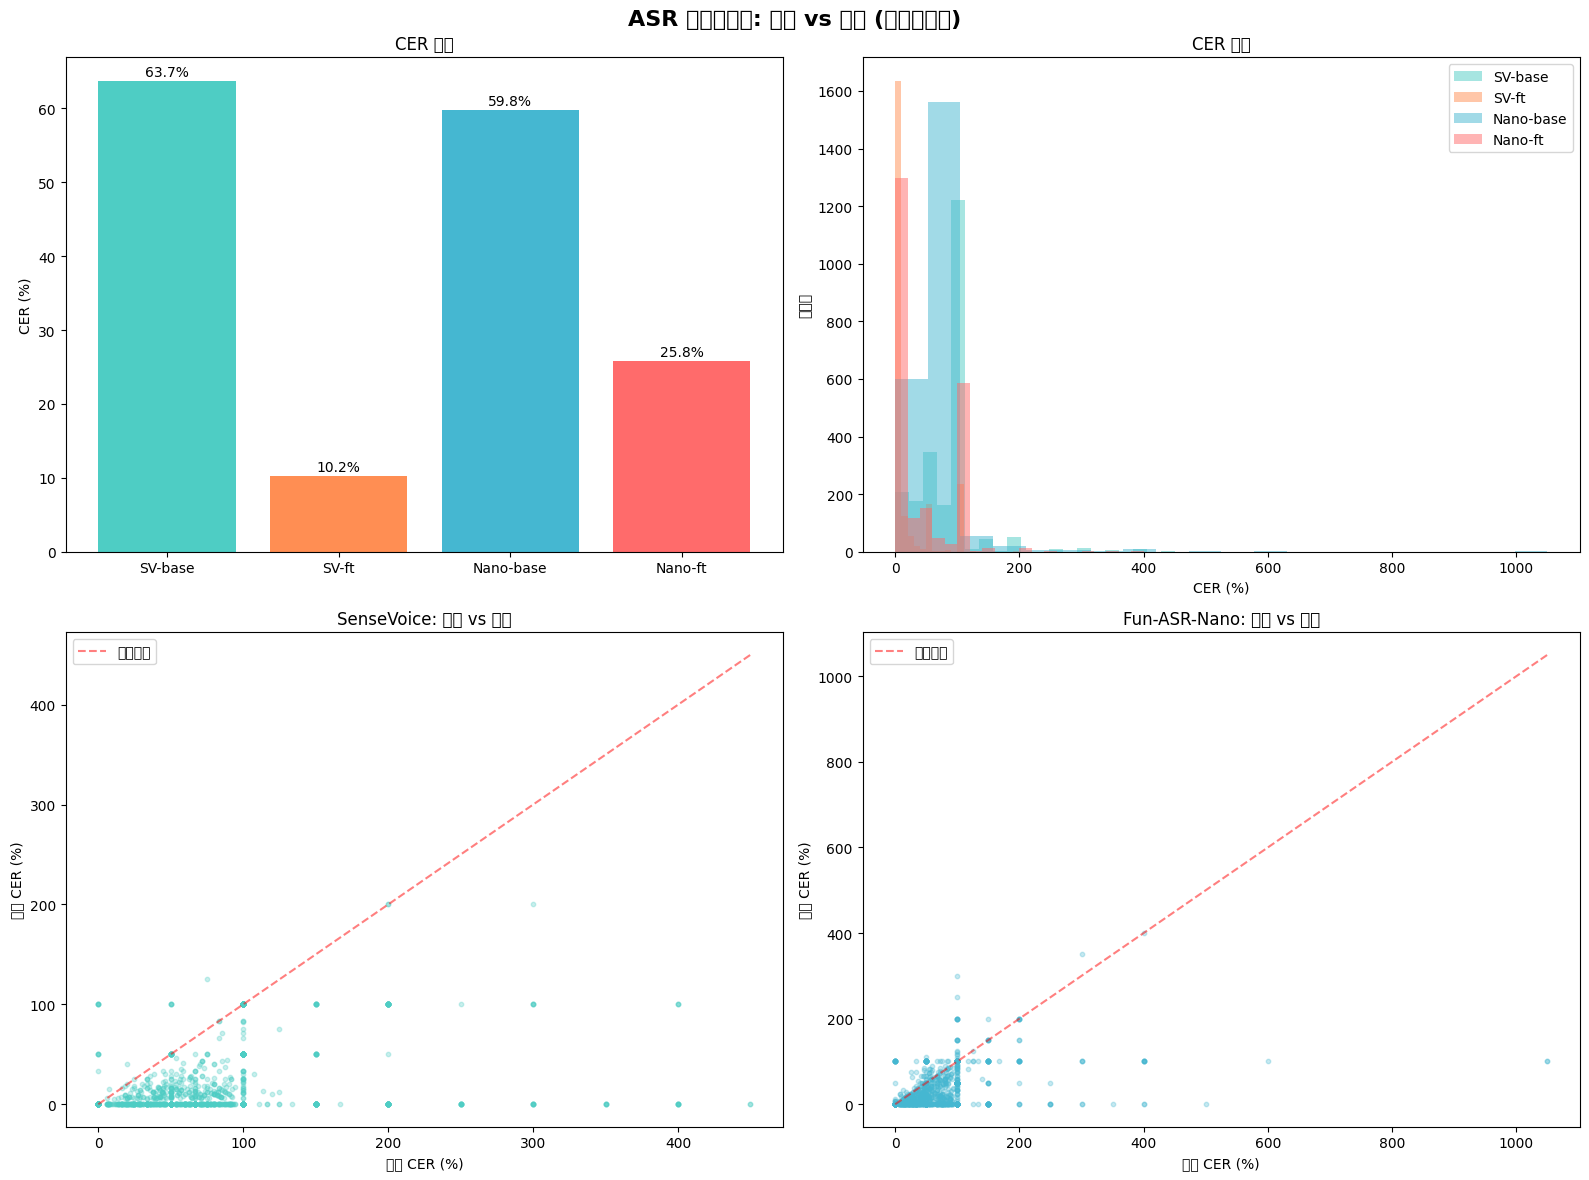

In [14]:
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('ASR 四模型对比: 基线 vs 微调 (全量验证集)', fontsize=16, fontweight='bold')

colors = ['#4ECDC4', '#FF8E53', '#45B7D1', '#FF6B6B']
cer_pcts = [r['cer'] * 100 for r in res_list]

# 1. CER 柱状图
bars = axes[0, 0].bar(ordered, cer_pcts, color=colors)
axes[0, 0].set_title('CER 对比')
axes[0, 0].set_ylabel('CER (%)')
for bar, cer in zip(bars, cer_pcts):
    axes[0, 0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.3, f'{cer:.1f}%', ha='center', va='bottom')

# 2. CER 分布直方图
for r, name, color in zip(res_list, ordered, colors):
    sample_cers = [s['cer'] * 100 for s in r['results']]
    axes[0, 1].hist(sample_cers, bins=20, alpha=0.5, label=name, color=color)
axes[0, 1].set_title('CER 分布')
axes[0, 1].set_xlabel('CER (%)')
axes[0, 1].set_ylabel('样本数')
axes[0, 1].legend()

# 3. SenseVoice: base vs ft 散点图
sv_base_cers = {s['id']: s['cer'] * 100 for s in sv_base_res['results']}
sv_ft_cers = {s['id']: s['cer'] * 100 for s in sv_ft_res['results']}
common_sv = sorted(set(sv_base_cers) & set(sv_ft_cers))
axes[1, 0].scatter([sv_base_cers[i] for i in common_sv], [sv_ft_cers[i] for i in common_sv], alpha=0.3, s=10, c='#4ECDC4')
max_cer = max(max(sv_base_cers.values()), max(sv_ft_cers.values()), 10)
axes[1, 0].plot([0, max_cer], [0, max_cer], 'r--', alpha=0.5, label='无变化线')
axes[1, 0].set_title('SenseVoice: 基线 vs 微调')
axes[1, 0].set_xlabel('基线 CER (%)')
axes[1, 0].set_ylabel('微调 CER (%)')
axes[1, 0].legend()

# 4. Nano: base vs ft 散点图
nano_base_cers = {s['id']: s['cer'] * 100 for s in nano_base_res['results']}
nano_ft_cers = {s['id']: s['cer'] * 100 for s in nano_ft_res['results']}
common_nano = sorted(set(nano_base_cers) & set(nano_ft_cers))
axes[1, 1].scatter([nano_base_cers[i] for i in common_nano], [nano_ft_cers[i] for i in common_nano], alpha=0.3, s=10, c='#45B7D1')
max_cer = max(max(nano_base_cers.values()), max(nano_ft_cers.values()), 10)
axes[1, 1].plot([0, max_cer], [0, max_cer], 'r--', alpha=0.5, label='无变化线')
axes[1, 1].set_title('Fun-ASR-Nano: 基线 vs 微调')
axes[1, 1].set_xlabel('基线 CER (%)')
axes[1, 1].set_ylabel('微调 CER (%)')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

## 10. 保存结果

In [15]:
REPORT_DIR = os.path.expanduser('~/Projects/Agent/local')

# 保存 JSON
compare_path = os.path.join(REPORT_DIR, 'model_comparison.json')
with open(compare_path, 'w', encoding='utf-8') as f:
    json.dump({
        'models': {
            r['name']: {
                'cer': round(r['cer'], 4),
                'exact_match': r['exact'],
                'total': r['total'],
                'exact_rate': round(r['exact'] / max(r['total'], 1), 4),
                'time': round(r['time'], 1),
                'speed': round(r['total'] / r['time'], 1) if r['time'] > 0 else 0,
            } for r in res_list
        },
        'samples': [
            {'id': idx,
             'expected': sv_base_map[idx]['expected'],
             'sv_base': sv_base_map[idx]['predicted'], 'sv_base_cer': sv_base_map[idx]['cer'],
             'sv_ft': sv_ft_map[idx]['predicted'], 'sv_ft_cer': sv_ft_map[idx]['cer'],
             'nano_base': nano_base_map[idx]['predicted'], 'nano_base_cer': nano_base_map[idx]['cer'],
             'nano_ft': nano_ft_map[idx]['predicted'], 'nano_ft_cer': nano_ft_map[idx]['cer']}
            for idx in common_ids
        ],
    }, f, ensure_ascii=False, indent=2)
print(f'对比结果已保存: {compare_path}')

对比结果已保存: /Users/fanhua/Projects/Agent/local/model_comparison.json


## 11. 可视化网页报告

生成交互式 HTML 报告，支持：
- 字符级 diff 高亮
- 按错误率筛选/排序
- 快速定位需要优化的录音样本

In [16]:
from difflib import SequenceMatcher
import html as html_mod

def char_diff(ref, hyp):
    """基于去标点文本做 diff，高亮错误"""
    sm = SequenceMatcher(None, ref, hyp)
    h_parts = []
    for op, i1, i2, j1, j2 in sm.get_opcodes():
        t = html_mod.escape(hyp[j1:j2])
        if op == 'equal':
            h_parts.append(t)
        elif op == 'replace':
            h_parts.append(f'<span class="sub">{t}</span>')
        elif op == 'insert':
            h_parts.append(f'<span class="ins">{t}</span>')
    return ''.join(h_parts)

def cer_badge(c):
    if c == 0: return '<span class="b ok">OK</span>'
    if c < 0.15: return f'<span class="b warn">{c:.0%}</span>'
    if c < 0.4: return f'<span class="b bad">{c:.0%}</span>'
    return f'<span class="b vbad">{c:.0%}</span>'

# 音频路径转换
AUDIO_ROOT = os.path.expanduser('~/Desktop/hengdong_asr_trainset/audio')

def audio_to_jupyter_path(abs_path):
    if abs_path.startswith(AUDIO_ROOT):
        rel = os.path.relpath(abs_path, AUDIO_ROOT)
        return f'audio_link/{rel}'
    return f'file://{abs_path}'

model_maps = [sv_base_map, sv_ft_map, nano_base_map, nano_ft_map]
model_col_names = ['SV-base', 'SV-ft', 'Nano-base', 'Nano-ft']

rows_html = []
for idx in common_ids:
    exp_raw = sv_base_map[idx]['expected']
    exp = norm_punct(exp_raw)
    audio = samples[idx].get('audio_filepath') or samples[idx].get('source') if idx < len(samples) else ''
    jupyter_audio = audio_to_jupyter_path(audio) if audio else ''

    cells = []
    for rmap in model_maps:
        pred = norm_punct(rmap[idx]['predicted'])
        c = rmap[idx]['cer']
        diff = char_diff(exp, pred) if c > 0 else '<span class="ok-text">OK</span>'
        cells.append(f'<td>{cer_badge(c)}<br><span class="t">{diff}</span></td>')
    worst = max(rmap[idx]['cer'] for rmap in model_maps)
    row_cls = 'error' if worst > 0 else 'match'
    audio_tag = f'<audio controls preload="none"><source src="{html_mod.escape(jupyter_audio)}"></audio>' if jupyter_audio else ''
    rows_html.append(
        f'<tr class="{row_cls}" data-c="{worst}">'
        f'<td class="id">{idx}</td>'
        f'<td>{audio_tag}</td>'
        f'<td class="ref">{html_mod.escape(exp)}</td>'
        + ''.join(cells) + '</tr>'
    )

summary_cards = ''
for r in res_list:
    summary_cards += (
        f'<div class="card"><h3>{r["name"]}</h3>'
        f'<p class="big">{r["cer"]:.2%}</p>'
        f'<p>exact: {r["exact"]}/{r["total"]}</p></div>'
    )

col_headers = ''.join(f'<th>{n}</th>' for n in model_col_names)

html_report = f"""<!DOCTYPE html>
<html lang="zh-CN">
<head><meta charset="UTF-8">
<meta name="viewport" content="width=device-width, initial-scale=1">
<title>ASR 四模型对比报告</title>
<style>
*{{box-sizing:border-box;margin:0;padding:0}}
body{{font-family:-apple-system,"PingFang SC","Microsoft YaHei",sans-serif;background:#f0f2f5;color:#333;padding:20px}}
h1{{text-align:center;margin-bottom:20px;font-size:22px}}
.summary{{display:flex;gap:12px;justify-content:center;margin-bottom:20px;flex-wrap:wrap}}
.card{{background:#fff;padding:14px 22px;border-radius:8px;box-shadow:0 1px 3px rgba(0,0,0,.1);text-align:center;min-width:140px}}
.card h3{{font-size:12px;color:#888;margin-bottom:6px}}
.card .big{{font-size:22px;font-weight:bold;color:#1890ff}}
.card p{{font-size:12px;color:#666;margin-top:4px}}
.toolbar{{background:#fff;padding:12px 16px;border-radius:8px;margin-bottom:12px;display:flex;gap:16px;align-items:center;flex-wrap:wrap;box-shadow:0 1px 3px rgba(0,0,0,.1)}}
.toolbar label{{font-size:13px;display:flex;align-items:center;gap:4px}}
.stats{{margin-left:auto;font-size:12px;color:#888}}
.wrap{{overflow-x:auto}}
table{{width:100%;border-collapse:collapse;background:#fff;box-shadow:0 1px 3px rgba(0,0,0,.1);font-size:13px}}
thead{{position:sticky;top:0;z-index:1}}
th{{background:#1a1a2e;color:#fff;padding:10px 8px;text-align:left;font-weight:500;white-space:nowrap}}
td{{padding:8px;border-bottom:1px solid #f0f0f0;vertical-align:top;max-width:280px;word-break:break-all}}
tr.error{{background:#fff5f5}}
tr.match{{background:#f6ffed}}
tr:hover{{filter:brightness(.97)}}
.id{{text-align:center;font-weight:bold;color:#666;min-width:40px}}
.ref{{font-weight:600;color:#333;min-width:80px}}
.t{{font-family:monospace;font-size:13px;line-height:1.8;display:inline-block}}
.b{{display:inline-block;padding:1px 6px;border-radius:3px;font-size:11px;font-weight:700;margin-bottom:2px}}
.b.ok{{background:#f6ffed;color:#52c41a;border:1px solid #b7eb8f}}
.b.warn{{background:#fffbe6;color:#faad14;border:1px solid #ffe58f}}
.b.bad{{background:#fff2f0;color:#ff4d4f;border:1px solid #ffccc7}}
.b.vbad{{background:#ff4d4f;color:#fff;border:1px solid #cf1322}}
.sub{{background:#ffe0b2;padding:0 1px;border-radius:2px;color:#e65100}}
.ins{{background:#c8e6c9;padding:0 1px;border-radius:2px;color:#1b5e20}}
.ok-text{{color:#52c41a;font-weight:600}}
audio{{height:30px;width:180px}}
</style></head><body>
<h1>ASR 四模型对比报告 (全量验证集, 标点归一化)</h1>
<div class="summary">{summary_cards}</div>
<div class="toolbar">
<label>Filter: <select id="filter" onchange="apply()">
<option value="all">All</option><option value="error">Errors</option><option value="match">Matches</option>
</select></label>
<label>Min CER: <input id="thr" type="range" min="0" max="100" value="0" oninput="apply()"> <span id="tv">0%</span></label>
<label>Sort: <select id="sort" onchange="apply()">
<option value="worst">Worst first</option><option value="id">By ID</option>
</select></label>
<span class="stats" id="stats"></span>
</div>
<div class="wrap"><table>
<thead><tr><th>ID</th><th>Audio</th><th>Expected</th>{col_headers}</tr></thead>
<tbody id="tbody">{''.join(rows_html)}</tbody>
</table></div>
<script>
function apply(){{
  const f=document.getElementById('filter').value;
  const t=document.getElementById('thr').value/100;
  const s=document.getElementById('sort').value;
  document.getElementById('tv').textContent=Math.round(t*100)+'%';
  let rows=Array.from(document.querySelectorAll('#tbody tr'));
  let vis=0;
  rows.forEach(r=>{{
    const c=parseFloat(r.dataset.c);
    let show=true;
    if(f==='error'&&c===0)show=false;
    if(f==='match'&&c>0)show=false;
    if(c<t)show=false;
    r.style.display=show?'':'none';
    if(show)vis++;
  }});
  if(s==='worst')rows.sort((a,b)=>parseFloat(b.dataset.c)-parseFloat(a.dataset.c));
  else rows.sort((a,b)=>parseInt(a.querySelector('.id').textContent)-parseInt(b.querySelector('.id').textContent));
  const tb=document.getElementById('tbody');
  rows.forEach(r=>tb.appendChild(r));
  document.getElementById('stats').textContent='Showing '+vis+' / '+rows.length;
}}
apply();
</script></body></html>"""

report_path = os.path.join(REPORT_DIR, 'asr_report.html')
with open(report_path, 'w', encoding='utf-8') as f:
    f.write(html_report)

error_count = sum(1 for r in rows_html if 'class="error"' in r)
print(f'HTML report: {report_path}')
print(f'Total: {len(rows_html)}, Errors: {error_count}')
print()
print('In Jupyter Lab: right-click asr_report.html -> Open in New Browser Tab')
print('Audio path: audio_link/... (served by Jupyter file server via symlink)')

HTML report: /Users/fanhua/Projects/Agent/local/asr_report.html
Total: 2261, Errors: 2184

In Jupyter Lab: right-click asr_report.html -> Open in New Browser Tab
Audio path: audio_link/... (served by Jupyter file server via symlink)


## 12. 长音频四模型对比 (VAD)

使用 VAD 分段 + 四模型串行评估长录音，生成 HTML 报告。

In [17]:
# 加载长音频数据
LONG_JSONL = os.path.join(DATA_ROOT, 'manifests/extra_long_talks.jsonl')
long_samples = []
with open(LONG_JSONL) as f:
    for line in f:
        item = json.loads(line)
        audio = item['audio_filepath']
        if audio.startswith('/mnt/data/'):
            audio = audio.replace('/mnt/data/hengdong_asr_trainset', DATA_ROOT)
        long_samples.append({
            'id': item['id'],
            'audio': audio,
            'text': item['text'],
            'duration': item['duration'],
            'speaker': item.get('speaker_id', 'unknown'),
        })
print(f'长音频: {len(long_samples)} 条')
for s in long_samples:
    exists = os.path.exists(s['audio'])
    print(f'  {s["speaker"]} | {s["duration"]/60:.1f}min | {"OK" if exists else "NOT FOUND"}')

长音频: 6 条
  talks_方言老女 | 27.1min | OK
  talks_方言老男 | 30.8min | OK
  talks_方言青女 | 23.3min | OK
  talks_方言青男 | 23.3min | OK
  dialogs_方言多人 | 16.7min | OK
  dialogs_方言多人 | 9.8min | OK


In [18]:
VAD_MODEL = 'iic/speech_fsmn_vad_zh-cn-16k-common-pytorch'
VAD_KWARGS = {'max_single_segment_time': 30000}

def eval_long_sensevoice(model, long_samples, label):
    """评估长音频 SenseVoice 模型 (VAD 内置)"""
    results = []
    start = time.time()
    for i, s in enumerate(long_samples):
        if not os.path.exists(s['audio']): continue
        print(f'  {label}: [{i+1}/{len(long_samples)}] {s["speaker"]} ({s["duration"]/60:.1f}min)')
        try:
            res = model.generate(input=s['audio'], language='auto', use_itn=True)
            pred_text = ''.join(clean_sensevoice_text(r['text']) for r in res if 'text' in r)
        except Exception as e:
            print(f'    Error: {e}')
            pred_text = ''
        exp_n = norm_punct(s['text'])
        pred_n = norm_punct(pred_text)
        cer = levenshtein(exp_n, pred_n) / max(len(exp_n), 1)
        results.append({
            'id': s['id'], 'speaker': s['speaker'], 'audio': s['audio'],
            'duration_min': s['duration'] / 60, 'cer': cer,
            'ref_len': len(exp_n), 'pred_len': len(pred_n),
            'expected': s['text'], 'predicted': pred_text,
        })
        print(f'    CER: {cer:.1%} | ref: {results[-1]["ref_len"]} | pred: {results[-1]["pred_len"]}')
    elapsed = time.time() - start
    avg_cer = sum(r['cer'] for r in results) / len(results) if results else 0
    return {'name': label, 'results': results, 'avg_cer': avg_cer, 'total': len(results), 'time': elapsed}

def eval_long_nano(vad_model, asr_model, long_samples, label):
    """评估长音频 Nano 模型 (手动 VAD 分段 + 逐段推理)"""
    results = []
    start = time.time()
    with torch.inference_mode():
        for i, s in enumerate(long_samples):
            if not os.path.exists(s['audio']): continue
            print(f'  {label}: [{i+1}/{len(long_samples)}] {s["speaker"]} ({s["duration"]/60:.1f}min)')
            try:
                # 1. VAD 分段
                vad_res = vad_model.generate(input=s['audio'])
                segments = vad_res[0]['value'] if vad_res and 'value' in vad_res[0] else []
                if not segments:
                    print(f'    VAD 未检测到语音段')
                    continue
                # 2. 逐段识别
                import torchaudio
                waveform, sr = torchaudio.load(s['audio'])
                if sr != 16000:
                    waveform = torchaudio.functional.resample(waveform, sr, 16000)
                    sr = 16000
                pred_parts = []
                for seg in segments:
                    start_sample = int(seg[0] * sr / 1000)
                    end_sample = int(seg[1] * sr / 1000)
                    chunk = waveform[:, start_sample:end_sample]
                    if chunk.shape[1] < sr * 0.3:  # 跳过 < 0.3s 的段
                        continue
                    # 保存临时文件
                    import tempfile, soundfile as sf
                    with tempfile.NamedTemporaryFile(suffix='.wav', delete=False) as tmp:
                        tmp_path = tmp.name
                    sf.write(tmp_path, chunk.squeeze().numpy(), sr)
                    try:
                        res = asr_model.generate(input=tmp_path, language='中文', itn=True)
                        if res and 'text' in res[0]:
                            pred_parts.append(res[0]['text'])
                    finally:
                        os.unlink(tmp_path)
                pred_text = ''.join(pred_parts)
            except Exception as e:
                print(f'    Error: {e}')
                pred_text = ''
            exp_n = norm_punct(s['text'])
            pred_n = norm_punct(pred_text)
            cer = levenshtein(exp_n, pred_n) / max(len(exp_n), 1)
            results.append({
                'id': s['id'], 'speaker': s['speaker'], 'audio': s['audio'],
                'duration_min': s['duration'] / 60, 'cer': cer,
                'ref_len': len(exp_n), 'pred_len': len(pred_n),
                'expected': s['text'], 'predicted': pred_text,
            })
            print(f'    CER: {cer:.1%} | ref: {results[-1]["ref_len"]} | pred: {results[-1]["pred_len"]} | segments: {len(segments) if "segments" in dir() else "?"}')
    elapsed = time.time() - start
    avg_cer = sum(r['cer'] for r in results) / len(results) if results else 0
    return {'name': label, 'results': results, 'avg_cer': avg_cer, 'total': len(results), 'time': elapsed}

print('长音频评估函数就绪')

长音频评估函数就绪


### 注意
长音频的参考文本是**摘要整理版**，而模型输出是**逐字转录版**，两者粒度不同。
因此 CER 偏高是正常现象，主要作为模型间横向对比参考。

### [1/4] SV-base (长音频)

In [19]:
long_all_results = {}

print('[1/4] SV-base (长音频)')
long_model = AutoModel(
    model='iic/SenseVoiceSmall', disable_update=True, device=device,
    vad_model=VAD_MODEL, vad_kwargs=VAD_KWARGS,
)
long_all_results['SV-base'] = eval_long_sensevoice(long_model, long_samples, 'SV-base')
print(f'  平均CER={long_all_results["SV-base"]["avg_cer"]:.1%} | 耗时={long_all_results["SV-base"]["time"]:.1f}s')

del long_model
free_memory()

[1/4] SV-base (长音频)
funasr version: 1.3.1.
  SV-base: [1/6] talks_方言老女 (27.1min)


100%|██████████| 141/141 [00:01<00:00, 72.76it/s]
{'load_data': '0.000', 'extract_feat': '0.154', 'forward': '1.938', 'batch_size': '141', 'rtf': '0.009'}, : 100%|██████████| 141/141 [00:01<00:00, 72.76it/s]
rtf_avg: 0.009: 100%|██████████| 141/141 [00:01<00:00, 72.70it/s]                                                                                            

100%|██████████| 94/94 [00:01<00:00, 53.62it/s]
{'load_data': '0.000', 'extract_feat': '0.145', 'forward': '1.753', 'batch_size': '94', 'rtf': '0.007'}, : 100%|██████████| 94/94 [00:01<00:00, 53.62it/s]
rtf_avg: 0.007: 100%|██████████| 94/94 [00:01<00:00, 53.58it/s]                                                                                           

100%|██████████| 67/67 [00:01<00:00, 41.52it/s]
{'load_data': '0.000', 'extract_feat': '0.128', 'forward': '1.735', 'batch_size': '67', 'rtf': '0.007'}, : 100%|██████████| 67/67 [00:01<00:00, 41.52it/s]
rtf_avg: 0.007: 100%|██████████| 67/67 [00:01<00:00, 41.48it/s]        

    CER: 419.9% | ref: 909 | pred: 4108
  SV-base: [2/6] talks_方言老男 (30.8min)


100%|██████████| 179/179 [00:02<00:00, 88.52it/s]
{'load_data': '0.000', 'extract_feat': '0.162', 'forward': '2.022', 'batch_size': '179', 'rtf': '0.008'}, : 100%|██████████| 179/179 [00:02<00:00, 88.52it/s]
rtf_avg: 0.008: 100%|██████████| 179/179 [00:02<00:00, 88.44it/s]                                                                                            

100%|██████████| 128/128 [00:01<00:00, 70.55it/s]
{'load_data': '0.000', 'extract_feat': '0.150', 'forward': '1.814', 'batch_size': '128', 'rtf': '0.007'}, : 100%|██████████| 128/128 [00:01<00:00, 70.55it/s]
rtf_avg: 0.007: 100%|██████████| 128/128 [00:01<00:00, 70.48it/s]                                                                                            

100%|██████████| 90/90 [00:01<00:00, 52.25it/s]
{'load_data': '0.000', 'extract_feat': '0.137', 'forward': '1.723', 'batch_size': '90', 'rtf': '0.007'}, : 100%|██████████| 90/90 [00:01<00:00, 52.25it/s]
rtf_avg: 0.007: 100%|██████████| 90/90 [00:01<00:00, 52.20it/s]

    CER: 253.9% | ref: 1268 | pred: 3745
  SV-base: [3/6] talks_方言青女 (23.3min)


...

    CER: 285.4% | ref: 1515 | pred: 4638
  SV-base: [5/6] dialogs_方言多人 (16.7min)


100%|██████████| 28/28 [00:02<00:00, 11.68it/s]
{'load_data': '0.000', 'extract_feat': '0.072', 'forward': '2.396', 'batch_size': '28', 'rtf': '0.017'}, : 100%|██████████| 28/28 [00:02<00:00, 11.68it/s]
rtf_avg: 0.017: 100%|██████████| 28/28 [00:02<00:00, 11.67it/s]                                                                                           

100%|██████████| 14/14 [00:03<00:00,  4.38it/s]
{'load_data': '0.000', 'extract_feat': '0.132', 'forward': '3.196', 'batch_size': '14', 'rtf': '0.012'}, : 100%|██████████| 14/14 [00:03<00:00,  4.38it/s]
rtf_avg: 0.012: 100%|██████████| 14/14 [00:03<00:00,  4.38it/s]                                                                                           

100%|██████████| 10/10 [00:02<00:00,  4.81it/s]
{'load_data': '0.000', 'extract_feat': '0.155', 'forward': '2.081', 'batch_size': '10', 'rtf': '0.007'}, : 100%|██████████| 10/10 [00:02<00:00,  4.81it/s]
rtf_avg: 0.007: 100%|██████████| 10/10 [00:02<00:00,  4.80it/s]                

    CER: 450.5% | ref: 311 | pred: 1466
  SV-base: [6/6] dialogs_方言多人 (9.8min)


100%|██████████| 22/22 [00:01<00:00, 11.11it/s]
{'load_data': '0.000', 'extract_feat': '0.077', 'forward': '1.981', 'batch_size': '22', 'rtf': '0.013'}, : 100%|██████████| 22/22 [00:01<00:00, 11.11it/s]
rtf_avg: 0.013: 100%|██████████| 22/22 [00:01<00:00, 11.10it/s]                                                                                           

100%|██████████| 10/10 [00:04<00:00,  2.05it/s]
{'load_data': '0.000', 'extract_feat': '0.117', 'forward': '4.879', 'batch_size': '10', 'rtf': '0.019'}, : 100%|██████████| 10/10 [00:04<00:00,  2.05it/s]
rtf_avg: 0.019: 100%|██████████| 10/10 [00:04<00:00,  2.05it/s]                                                                                           

100%|██████████| 5/5 [00:01<00:00,  4.38it/s]
{'load_data': '0.000', 'extract_feat': '0.070', 'forward': '1.142', 'batch_size': '5', 'rtf': '0.008'}, : 100%|██████████| 5/5 [00:01<00:00,  4.38it/s]
rtf_avg: 0.008: 100%|██████████| 5/5 [00:01<00:00,  4.37it/s]                       

    CER: 576.5% | ref: 204 | pred: 1256
  平均CER=456.7% | 耗时=67.4s


### [2/4] SV-ft (微调) (长音频)

In [20]:
print('[2/4] SV-ft (长音频)')
long_model = AutoModel(
    model='iic/SenseVoiceSmall', lora_only=True, disable_update=True, device=device,
    vad_model=VAD_MODEL, vad_kwargs=VAD_KWARGS,
)
long_ckpt = torch.load(SV_CKPT, map_location='cpu', weights_only=False)
long_model.model.load_state_dict(long_ckpt['state_dict'], strict=False)
del long_ckpt
print('  微调权重已载入')

long_all_results['SV-ft'] = eval_long_sensevoice(long_model, long_samples, 'SV-ft')
print(f'  平均CER={long_all_results["SV-ft"]["avg_cer"]:.1%} | 耗时={long_all_results["SV-ft"]["time"]:.1f}s')

del long_model
free_memory()

[2/4] SV-ft (长音频)
funasr version: 1.3.1.
  微调权重已载入
  SV-ft: [1/6] talks_方言老女 (27.1min)


100%|██████████| 141/141 [00:01<00:00, 73.87it/s]
{'load_data': '0.000', 'extract_feat': '0.177', 'forward': '1.909', 'batch_size': '141', 'rtf': '0.009'}, : 100%|██████████| 141/141 [00:01<00:00, 73.87it/s]
rtf_avg: 0.009: 100%|██████████| 141/141 [00:01<00:00, 73.82it/s]                                                                                            

100%|██████████| 94/94 [00:01<00:00, 53.12it/s]
{'load_data': '0.000', 'extract_feat': '0.163', 'forward': '1.769', 'batch_size': '94', 'rtf': '0.007'}, : 100%|██████████| 94/94 [00:01<00:00, 53.12it/s]
rtf_avg: 0.007: 100%|██████████| 94/94 [00:01<00:00, 53.08it/s]                                                                                           

100%|██████████| 67/67 [00:01<00:00, 38.92it/s]
{'load_data': '0.000', 'extract_feat': '0.144', 'forward': '1.722', 'batch_size': '67', 'rtf': '0.007'}, : 100%|██████████| 67/67 [00:01<00:00, 38.92it/s]
rtf_avg: 0.007: 100%|██████████| 67/67 [00:01<00:00, 38.88it/s]        

    CER: 392.8% | ref: 909 | pred: 3983
  SV-ft: [2/6] talks_方言老男 (30.8min)


100%|██████████| 179/179 [00:02<00:00, 89.33it/s]
{'load_data': '0.000', 'extract_feat': '0.207', 'forward': '2.004', 'batch_size': '179', 'rtf': '0.008'}, : 100%|██████████| 179/179 [00:02<00:00, 89.33it/s]
rtf_avg: 0.008: 100%|██████████| 179/179 [00:02<00:00, 89.25it/s]                                                                                            

100%|██████████| 128/128 [00:01<00:00, 70.43it/s]
{'load_data': '0.000', 'extract_feat': '0.177', 'forward': '1.817', 'batch_size': '128', 'rtf': '0.007'}, : 100%|██████████| 128/128 [00:01<00:00, 70.43it/s]
rtf_avg: 0.007: 100%|██████████| 128/128 [00:01<00:00, 70.37it/s]                                                                                            

100%|██████████| 90/90 [00:01<00:00, 52.30it/s]
{'load_data': '0.000', 'extract_feat': '0.155', 'forward': '1.721', 'batch_size': '90', 'rtf': '0.007'}, : 100%|██████████| 90/90 [00:01<00:00, 52.30it/s]
rtf_avg: 0.007: 100%|██████████| 90/90 [00:01<00:00, 52.25it/s]

    CER: 219.6% | ref: 1268 | pred: 3624
  SV-ft: [3/6] talks_方言青女 (23.3min)


...

    CER: 272.7% | ref: 1515 | pred: 4497
  SV-ft: [5/6] dialogs_方言多人 (16.7min)


100%|██████████| 28/28 [00:02<00:00, 12.20it/s]
{'load_data': '0.000', 'extract_feat': '0.074', 'forward': '2.295', 'batch_size': '28', 'rtf': '0.017'}, : 100%|██████████| 28/28 [00:02<00:00, 12.20it/s]
rtf_avg: 0.017: 100%|██████████| 28/28 [00:02<00:00, 12.18it/s]                                                                                           

100%|██████████| 14/14 [00:03<00:00,  4.42it/s]
{'load_data': '0.000', 'extract_feat': '0.143', 'forward': '3.168', 'batch_size': '14', 'rtf': '0.012'}, : 100%|██████████| 14/14 [00:03<00:00,  4.42it/s]
rtf_avg: 0.012: 100%|██████████| 14/14 [00:03<00:00,  4.42it/s]                                                                                           

100%|██████████| 10/10 [00:02<00:00,  4.85it/s]
{'load_data': '0.000', 'extract_feat': '0.151', 'forward': '2.060', 'batch_size': '10', 'rtf': '0.007'}, : 100%|██████████| 10/10 [00:02<00:00,  4.85it/s]
rtf_avg: 0.007: 100%|██████████| 10/10 [00:02<00:00,  4.85it/s]                

    CER: 435.7% | ref: 311 | pred: 1445
  SV-ft: [6/6] dialogs_方言多人 (9.8min)


100%|██████████| 22/22 [00:01<00:00, 11.56it/s]
{'load_data': '0.000', 'extract_feat': '0.082', 'forward': '1.903', 'batch_size': '22', 'rtf': '0.012'}, : 100%|██████████| 22/22 [00:01<00:00, 11.56it/s]
rtf_avg: 0.012: 100%|██████████| 22/22 [00:01<00:00, 11.55it/s]                                                                                           

100%|██████████| 10/10 [00:05<00:00,  1.88it/s]
{'load_data': '0.000', 'extract_feat': '0.118', 'forward': '5.306', 'batch_size': '10', 'rtf': '0.021'}, : 100%|██████████| 10/10 [00:05<00:00,  1.88it/s]
rtf_avg: 0.021: 100%|██████████| 10/10 [00:05<00:00,  1.88it/s]                                                                                           

100%|██████████| 5/5 [00:01<00:00,  3.59it/s]
{'load_data': '0.000', 'extract_feat': '0.072', 'forward': '1.393', 'batch_size': '5', 'rtf': '0.009'}, : 100%|██████████| 5/5 [00:01<00:00,  3.59it/s]
rtf_avg: 0.009: 100%|██████████| 5/5 [00:01<00:00,  3.58it/s]                       

    CER: 683.3% | ref: 204 | pred: 1504
  平均CER=477.2% | 耗时=66.7s


### [3/4] Nano-base (长音频)

In [21]:
print('[3/4] Nano-base (长音频)')
# Nano 不支持内置 VAD，需要手动分段
vad_only = AutoModel(model=VAD_MODEL, disable_update=True, device=device)
nano_base = AutoModel(model='FunAudioLLM/Fun-ASR-Nano-2512', hub='ms', disable_update=True, device=device)

long_all_results['Nano-base'] = eval_long_nano(vad_only, nano_base, long_samples, 'Nano-base')
print(f'  平均CER={long_all_results["Nano-base"]["avg_cer"]:.1%} | 耗时={long_all_results["Nano-base"]["time"]:.1f}s')

del vad_only, nano_base
free_memory()

[3/4] Nano-base (长音频)
funasr version: 1.3.1.
funasr version: 1.3.1.
  Nano-base: [1/6] talks_方言老女 (27.1min)


rtf_avg: 0.182: 100%|██████████| 1/1 [00:01<00:00,  1.52s/it]                                                                                          


    Error: TorchCodec is required for load_with_torchcodec. Please install torchcodec to use this function.
    CER: 100.0% | ref: 909 | pred: 0 | segments: 373
  Nano-base: [2/6] talks_方言老男 (30.8min)


rtf_avg: 0.038: 100%|██████████| 1/1 [00:01<00:00,  1.71s/it]                                                                                          


    Error: TorchCodec is required for load_with_torchcodec. Please install torchcodec to use this function.
    CER: 100.0% | ref: 1268 | pred: 0 | segments: 477
  Nano-base: [3/6] talks_方言青女 (23.3min)


...

    Error: TorchCodec is required for load_with_torchcodec. Please install torchcodec to use this function.
    CER: 100.0% | ref: 1515 | pred: 0 | segments: 208
  Nano-base: [5/6] dialogs_方言多人 (16.7min)


rtf_avg: 0.024: 100%|██████████| 1/1 [00:00<00:00,  1.02it/s]                                                                                          


    Error: TorchCodec is required for load_with_torchcodec. Please install torchcodec to use this function.
    CER: 100.0% | ref: 311 | pred: 0 | segments: 46
  Nano-base: [6/6] dialogs_方言多人 (9.8min)


rtf_avg: 0.013: 100%|██████████| 1/1 [00:00<00:00,  1.64it/s]                                                                                          

    Error: TorchCodec is required for load_with_torchcodec. Please install torchcodec to use this function.
    CER: 100.0% | ref: 204 | pred: 0 | segments: 30
  平均CER=100.0% | 耗时=7.4s


### [4/4] Nano-ft (微调) (长音频)

In [22]:
print('[4/4] Nano-ft (长音频)')
vad_only = AutoModel(model=VAD_MODEL, disable_update=True, device=device)
nano_ft = AutoModel(
    model='FunAudioLLM/Fun-ASR-Nano-2512', hub='ms', disable_update=True, device=device,
    init_param=NANO_CKPT,
)
print('  微调权重已载入')

long_all_results['Nano-ft'] = eval_long_nano(vad_only, nano_ft, long_samples, 'Nano-ft')
print(f'  平均CER={long_all_results["Nano-ft"]["avg_cer"]:.1%} | 耗时={long_all_results["Nano-ft"]["time"]:.1f}s')

del vad_only, nano_ft
free_memory()

[4/4] Nano-ft (长音频)
funasr version: 1.3.1.
funasr version: 1.3.1.
  微调权重已载入
  Nano-ft: [1/6] talks_方言老女 (27.1min)


rtf_avg: 0.200: 100%|██████████| 1/1 [00:01<00:00,  1.67s/it]                                                                                          


    Error: TorchCodec is required for load_with_torchcodec. Please install torchcodec to use this function.
    CER: 100.0% | ref: 909 | pred: 0 | segments: 373
  Nano-ft: [2/6] talks_方言老男 (30.8min)


rtf_avg: 0.038: 100%|██████████| 1/1 [00:01<00:00,  1.71s/it]                                                                                          


    Error: TorchCodec is required for load_with_torchcodec. Please install torchcodec to use this function.
    CER: 100.0% | ref: 1268 | pred: 0 | segments: 477
  Nano-ft: [3/6] talks_方言青女 (23.3min)


...

    Error: TorchCodec is required for load_with_torchcodec. Please install torchcodec to use this function.
    CER: 100.0% | ref: 1515 | pred: 0 | segments: 208
  Nano-ft: [5/6] dialogs_方言多人 (16.7min)


rtf_avg: 0.023: 100%|██████████| 1/1 [00:00<00:00,  1.04it/s]                                                                                          


    Error: TorchCodec is required for load_with_torchcodec. Please install torchcodec to use this function.
    CER: 100.0% | ref: 311 | pred: 0 | segments: 46
  Nano-ft: [6/6] dialogs_方言多人 (9.8min)


rtf_avg: 0.013: 100%|██████████| 1/1 [00:00<00:00,  1.65it/s]                                                                                          


    Error: TorchCodec is required for load_with_torchcodec. Please install torchcodec to use this function.
    CER: 100.0% | ref: 204 | pred: 0 | segments: 30
  平均CER=100.0% | 耗时=7.6s


In [23]:
long_ordered = ['SV-base', 'SV-ft', 'Nano-base', 'Nano-ft']
long_res_list = [long_all_results[n] for n in long_ordered]

print('=' * 75)
print('长音频四模型对比汇总')
print('=' * 75)
print(f'{"模型":<14} {"平均CER":>8} {"样本":>6} {"平均ref":>8} {"平均pred":>8} {"耗时":>10}')
print('-' * 65)
for r in long_res_list:
    avg_ref = sum(s['ref_len'] for s in r['results']) / max(r['total'], 1)
    avg_pred = sum(s['pred_len'] for s in r['results']) / max(r['total'], 1)
    print(f'{r["name"]:<14} {r["avg_cer"]:>7.1%} {r["total"]:>6} {avg_ref:>8.0f} {avg_pred:>8.0f} {r["time"]:>9.1f}s')
print('=' * 75)

cers = [r['avg_cer'] for r in long_res_list]
sv_imp = (cers[0] - cers[1]) / cers[0] * 100 if cers[0] > 0 else 0
nano_imp = (cers[2] - cers[3]) / cers[2] * 100 if cers[2] > 0 else 0
print(f'SV微调提升: {sv_imp:+.1f}%')
print(f'Nano微调提升: {nano_imp:+.1f}%')
print(f'\n注: CER 偏高是因为参考文本是摘要版，模型输出是逐字转录版，两者粒度不同')

long_eval_path = os.path.join(REPORT_DIR, 'long_audio_eval.json')
with open(long_eval_path, 'w', encoding='utf-8') as f:
    json.dump({
        'models': {
            r['name']: {'avg_cer': round(r['avg_cer'], 4), 'total': r['total'],
                        'time': round(r['time'], 1), 'results': r['results']}
            for r in long_res_list
        },
    }, f, ensure_ascii=False, indent=2)
print(f'\n结果已保存: {long_eval_path}')

长音频四模型对比汇总
模型                平均CER     样本    平均ref   平均pred         耗时
-----------------------------------------------------------------
SV-base         456.7%      6      784     3189      67.4s
SV-ft           477.2%      6      784     3253      66.7s
Nano-base       100.0%      6      784        0       7.4s
Nano-ft         100.0%      6      784        0       7.6s
SV微调提升: -4.5%
Nano微调提升: +0.0%

注: CER 偏高是因为参考文本是摘要版，模型输出是逐字转录版，两者粒度不同

结果已保存: /Users/fanhua/Projects/Agent/local/long_audio_eval.json


In [24]:
AUDIO_SYMLINKS = {
    os.path.expanduser('~/Desktop/hengdong_asr_trainset/audio_extra'): 'audio_extra_link',
    os.path.expanduser('~/Desktop/hengdong_asr_trainset/audio'): 'audio_link',
}

def audio_to_jupyter_path(abs_path):
    for root, link_name in AUDIO_SYMLINKS.items():
        if abs_path.startswith(root):
            rel = os.path.relpath(abs_path, root)
            return f'{link_name}/{rel}'
    return f'file://{abs_path}'

long_model_maps = {n: {r['id']: r for r in long_all_results[n]['results']} for n in long_ordered}
common_long_ids = sorted(set.intersection(*[set(m.keys()) for m in long_model_maps.values()]))

long_rows = []
for sid in common_long_ids:
    ref_r = long_model_maps[long_ordered[0]][sid]
    exp = norm_punct(ref_r['expected'])
    jupyter_audio = audio_to_jupyter_path(ref_r['audio']) if ref_r['audio'] else ''
    audio_tag = f'<audio controls preload="none"><source src="{html_mod.escape(jupyter_audio)}"></audio>' if jupyter_audio else ''

    cells = []
    worst = 0
    for n in long_ordered:
        mr = long_model_maps[n][sid]
        pred = norm_punct(mr['predicted'])
        c = mr['cer']
        worst = max(worst, c)
        diff = char_diff(exp, pred[:len(exp)+50]) if c > 0 else '<span class="ok-text">OK</span>'
        cells.append(f'<td>{cer_badge(c)}<br><span class="t">{diff}</span></td>')

    row_cls = 'error' if worst > 0 else 'match'
    long_rows.append(
        f'<tr class="{row_cls}" data-c="{worst}">'
        f'<td class="id">{html_mod.escape(str(sid))}</td>'
        f'<td>{audio_tag}</td>'
        f'<td>{html_mod.escape(ref_r["speaker"])}</td>'
        f'<td>{ref_r["duration_min"]:.1f}m</td>'
        f'<td class="ref">{html_mod.escape(exp[:200])}</td>'
        + ''.join(cells) + '</tr>'
    )

long_cards = ''
for r in long_res_list:
    long_cards += (
        f'<div class="card"><h3>{r["name"]}</h3>'
        f'<p class="big">{r["avg_cer"]:.1%}</p>'
        f'<p>samples: {r["total"]}</p></div>'
    )

long_col_headers = ''.join(f'<th>{n}</th>' for n in long_ordered)

long_html = f"""<!DOCTYPE html>
<html lang="zh-CN">
<head><meta charset="UTF-8">
<meta name="viewport" content="width=device-width, initial-scale=1">
<title>长音频 ASR 四模型对比报告</title>
<style>
*{{box-sizing:border-box;margin:0;padding:0}}
body{{font-family:-apple-system,"PingFang SC","Microsoft YaHei",sans-serif;background:#f0f2f5;color:#333;padding:20px}}
h1{{text-align:center;margin-bottom:20px;font-size:22px}}
.note{{text-align:center;color:#888;font-size:13px;margin-bottom:16px}}
.summary{{display:flex;gap:12px;justify-content:center;margin-bottom:20px;flex-wrap:wrap}}
.card{{background:#fff;padding:14px 22px;border-radius:8px;box-shadow:0 1px 3px rgba(0,0,0,.1);text-align:center;min-width:140px}}
.card h3{{font-size:12px;color:#888;margin-bottom:6px}}
.card .big{{font-size:22px;font-weight:bold;color:#1890ff}}
.card p{{font-size:12px;color:#666;margin-top:4px}}
.toolbar{{background:#fff;padding:12px 16px;border-radius:8px;margin-bottom:12px;display:flex;gap:16px;align-items:center;flex-wrap:wrap;box-shadow:0 1px 3px rgba(0,0,0,.1)}}
.toolbar label{{font-size:13px;display:flex;align-items:center;gap:4px}}
.stats{{margin-left:auto;font-size:12px;color:#888}}
.wrap{{overflow-x:auto}}
table{{width:100%;border-collapse:collapse;background:#fff;box-shadow:0 1px 3px rgba(0,0,0,.1);font-size:13px}}
thead{{position:sticky;top:0;z-index:1}}
th{{background:#1a1a2e;color:#fff;padding:10px 8px;text-align:left;font-weight:500;white-space:nowrap}}
td{{padding:8px;border-bottom:1px solid #f0f0f0;vertical-align:top;max-width:320px;word-break:break-all}}
tr.error{{background:#fff5f5}}
tr.match{{background:#f6ffed}}
tr:hover{{filter:brightness(.97)}}
.id{{text-align:center;font-weight:bold;color:#666;min-width:40px}}
.ref{{font-weight:600;color:#333;min-width:120px}}
.t{{font-family:monospace;font-size:12px;line-height:1.8;display:inline-block}}
.b{{display:inline-block;padding:1px 6px;border-radius:3px;font-size:11px;font-weight:700;margin-bottom:2px}}
.b.ok{{background:#f6ffed;color:#52c41a;border:1px solid #b7eb8f}}
.b.warn{{background:#fffbe6;color:#faad14;border:1px solid #ffe58f}}
.b.bad{{background:#fff2f0;color:#ff4d4f;border:1px solid #ffccc7}}
.b.vbad{{background:#ff4d4f;color:#fff;border:1px solid #cf1322}}
.sub{{background:#ffe0b2;padding:0 1px;border-radius:2px;color:#e65100}}
.ins{{background:#c8e6c9;padding:0 1px;border-radius:2px;color:#1b5e20}}
.ok-text{{color:#52c41a;font-weight:600}}
audio{{height:30px;width:180px}}
</style></head><body>
<h1>长音频 ASR 四模型对比报告</h1>
<p class="note">注: CER 偏高是因为参考文本是摘要整理版，模型输出是逐字转录版，两者粒度不同</p>
<div class="summary">{long_cards}</div>
<div class="toolbar">
<label>Filter: <select id="filter" onchange="apply()">
<option value="all">All</option><option value="error">Errors</option><option value="match">Matches</option>
</select></label>
<label>Min CER: <input id="thr" type="range" min="0" max="100" value="0" oninput="apply()"> <span id="tv">0%</span></label>
<span class="stats" id="stats"></span>
</div>
<div class="wrap"><table>
<thead><tr><th>ID</th><th>Audio</th><th>Speaker</th><th>Duration</th><th>Expected</th>{long_col_headers}</tr></thead>
<tbody id="tbody">{''.join(long_rows)}</tbody>
</table></div>
<script>
function apply(){{
  const f=document.getElementById('filter').value;
  const t=document.getElementById('thr').value/100;
  document.getElementById('tv').textContent=Math.round(t*100)+'%';
  let rows=Array.from(document.querySelectorAll('#tbody tr'));
  let vis=0;
  rows.forEach(r=>{{
    const c=parseFloat(r.dataset.c);
    let show=true;
    if(f==='error'&&c===0)show=false;
    if(f==='match'&&c>0)show=false;
    if(c<t)show=false;
    r.style.display=show?'':'none';
    if(show)vis++;
  }});
  document.getElementById('stats').textContent='Showing '+vis+' / '+rows.length;
}}
apply();
</script></body></html>"""

long_report_path = os.path.join(REPORT_DIR, 'long_audio_report.html')
with open(long_report_path, 'w', encoding='utf-8') as f:
    f.write(long_html)

print(f'HTML report: {long_report_path}')
print(f'Total samples: {len(long_rows)}')
print('In Jupyter Lab: right-click long_audio_report.html -> Open in New Browser Tab')

HTML report: /Users/fanhua/Projects/Agent/local/long_audio_report.html
Total samples: 6
In Jupyter Lab: right-click long_audio_report.html -> Open in New Browser Tab
